# Codon-Anticodon RMSD Analysis

This notebook analyzes codon-anticodon base pair RMSD at three positions:
- **Position 1**: First codon-anticodon base pair
- **Position 2**: Second codon-anticodon base pair
- **Position 3**: Third (wobble) codon-anticodon base pair

## Analyses:
1. Time-series plots: Individual position RMSD over time
2. Block averaging: Convergence assessment using adjacent block t-test
3. Bar plots with statistical testing: Cross-system comparisons

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import re
from scipy import stats
from scipy.signal import savgol_filter

# Set plotting style
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

## Configuration

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

# Data directory
DATA_DIR = Path('../data/rmsd')

# Time conversion
TIME_STEP = 0.1  # ns per frame

# Frame ranges
PLOT_START_FRAME = 0
PLOT_END_FRAME = 23000

# Bar plot figure size (width, height) per subplot
BAR_SUBPLOT_SIZE = (4, 4)

# Positions to analyze
POSITIONS = ['codon_anticodon_pos1', 'codon_anticodon_pos2', 'codon_anticodon_pos3', 
             'anticodon_stem','anticodon_stem_heavy', 'codon_anticodon', 'codon_anticodon_heavy', 'codon_anticodon_eIF5_GNG']
POSITION_LABELS = {
    'codon_anticodon_pos1': 'Position 1 (First Base Pair)',
    'codon_anticodon_pos2': 'Position 2 (Second Base Pair)',
    'codon_anticodon_pos3': 'Position 3 (Wobble)', 
    'anticodon_stem': 'Anticodon Stem',
    'anticodon_stem_heavy': 'Anticodon Stem (Heavy)',
    'codon_anticodon': 'Codon-Anticodon',
    'codon_anticodon_heavy': 'Codon-Anticodon (Heavy)',
    'codon_anticodon_eIF5_GNG' : 'codon_anticodon_eIF5_GNG'
}

# System definitions
SYSTEMS = [
    'eIF5wt_AUG', 'eIF5wt_ACG', 'eIF5wt_CUG', 'eIF5wt_UUG', 'eIF5wt_AUC',
    'eIF5wt_GUG', 'eIF5_N30K_AUG', 'eIF5_N30Q_AUG', 'eIF5_G29A_G31A_AUG'
]
SYSTEM_LABELS = {
    'eIF5wt_AUG': 'wt/AUG',
    'eIF5wt_ACG': 'wt/ACG',
    'eIF5wt_CUG': 'wt/CUG',
    'eIF5wt_UUG': 'wt/UUG',
    'eIF5wt_AUC': 'wt/AUC',
    'eIF5_N30K_AUG': 'N30K/AUG',
    'eIF5_N30Q_AUG': 'N30Q/AUG',
    'eIF5_G29A_G31A_AUG': 'G29A_G31A/AUG',
    'eIF5wt_GUG': 'wt/GUG',
}

# Control system for statistical testing
CONTROL_SYSTEM = 'eIF5wt_AUG'

# Number of clones
N_CLONES = 8

# Color palette for systems (keys match SYSTEMS list)
SYSTEM_COLORS_MAP = {
    'eIF5wt_AUG': '#002849',
    'eIF5wt_ACG': '#6daa48',
    'eIF5wt_CUG': '#2ba7d8',
    'eIF5wt_UUG': '#6a3a74',
    'eIF5wt_AUC': '#faa41a',
    'eIF5_N30K_AUG': '#067f92',
    'eIF5_N30Q_AUG': '#3954a4',
    'eIF5_G29A_G31A_AUG': '#f37039'
}

## Data Loading Functions

In [3]:
def parse_filename(filename: str, positions: List[str] = POSITIONS) -> Optional[Dict[str, str]]:
    """
    Extract system information from RMSD filename.

    Args:
        filename: RMSD data filename
        positions: List of valid position names to match

    Returns:
        Dictionary with date, variant, codon, clone, position, and system keys.
        Returns None if filename does not match expected pattern.
    """
    # Build position pattern dynamically from POSITIONS list
    escaped_positions = [re.escape(pos) for pos in positions]
    position_pattern = '|'.join(escaped_positions)

    pattern = rf'(\d{{8}})_48S_(eIF5.*?)_(AUG|ACG|CUG|UUG|AUC|GUG)_clone(\d+)-({position_pattern})-rmsd\.dat'
    match = re.match(pattern, filename)

    if match:
        variant = match.group(2)
        codon = match.group(3)
        return {
            'date': match.group(1),
            'variant': variant,
            'codon': codon,
            'clone': match.group(4),
            'position': match.group(5),
            'system': f"{variant}_{codon}"
        }
    return None


def load_rmsd_file(filepath: Path) -> np.ndarray:
    """
    Load RMSD data from a single file.

    Args:
        filepath: Path to RMSD .dat file

    Returns:
        Array of RMSD values (in Angstroms)
    """
    data = np.loadtxt(filepath, skiprows=1, usecols=1)
    return data


def load_codon_anticodon_rmsd(positions: List[str] = POSITIONS) -> Dict[str, Dict[str, Dict[str, np.ndarray]]]:
    """
    Load all codon_anticodon position RMSD files.

    Args:
        positions: List of position names to load

    Returns:
        Nested dictionary: system -> position -> clone -> rmsd_array
    """
    rmsd_data: Dict[str, Dict[str, Dict[str, np.ndarray]]] = {}

    # Load files for each position in the POSITIONS list
    for position in positions:
        for filepath in sorted(DATA_DIR.glob(f'*-{position}-rmsd.dat')):
            info = parse_filename(filepath.name, positions)
            if info is None:
                continue

            system = info['system']
            pos = info['position']
            clone = info['clone']

            # Initialize nested dictionaries
            if system not in rmsd_data:
                rmsd_data[system] = {}
            if pos not in rmsd_data[system]:
                rmsd_data[system][pos] = {}

            rmsd_data[system][pos][clone] = load_rmsd_file(filepath)

    return rmsd_data


# Load all data
print("Loading dat files...")
all_data = load_codon_anticodon_rmsd()
print(f"Loaded {len(all_data)} systems")
for system in SYSTEMS:
    if system in all_data:
        n_clones = len(list(all_data[system].values())[0]) if all_data[system] else 0
        n_positions = len(all_data[system])
        print(f"  {system}: {n_clones} clones, {n_positions} positions")

Loading dat files...
Loaded 9 systems
  eIF5wt_AUG: 8 clones, 8 positions
  eIF5wt_ACG: 8 clones, 8 positions
  eIF5wt_CUG: 8 clones, 8 positions
  eIF5wt_UUG: 8 clones, 8 positions
  eIF5wt_AUC: 8 clones, 8 positions
  eIF5wt_GUG: 8 clones, 8 positions
  eIF5_N30K_AUG: 8 clones, 8 positions
  eIF5_N30Q_AUG: 8 clones, 8 positions
  eIF5_G29A_G31A_AUG: 8 clones, 8 positions


### Generate time series RMSD for codon anticodon eIF5 GNG

In [7]:
def plot_rmsd_timeseries(
    all_data: Dict[str, Dict[str, Dict[str, np.ndarray]]],
    position: str,
    time_step: float = TIME_STEP,
    start_frame: int = PLOT_START_FRAME,
    end_frame: int = PLOT_END_FRAME
) -> plt.Figure:
    """
    Plot RMSD time series for a single position across all systems.
    
    Creates a figure with 8 subplots (2 rows x 4 columns), one per system.
    Each subplot shows 8 replicate lines.
    
    Args:
        all_data: Complete RMSD dataset (system -> position -> clone -> array)
        position: Position to plot (e.g., 'codon_anticodon_pos1')
        time_step: Time per frame in ns
        start_frame: First frame to plot
        end_frame: Last frame to plot
        
    Returns:
        matplotlib Figure object
    """
    fig, axes = plt.subplots(3, 4, figsize=(16, 6))
    axes = axes.flatten()
    
    position_label = POSITION_LABELS.get(position, position)
    fig.suptitle(f'{position_label} RMSD Time Series [Frames {start_frame}-{end_frame}]',
                 fontsize=14, fontweight='bold')
    
    # Color palette for clones
    clone_colors = sns.color_palette('tab10', n_colors=N_CLONES)
    
    for idx, system in enumerate(SYSTEMS):
        ax = axes[idx]
        
        if system in all_data and position in all_data[system]:
            clone_data = all_data[system][position]
            
            for clone_id, rmsd_values in sorted(clone_data.items(), key=lambda x: int(x[0])):
                rmsd_slice = rmsd_values[start_frame:end_frame]
                smooth_rmsd = savgol_filter(rmsd_slice, 1000, 3)
                time = (np.arange(len(smooth_rmsd)) + start_frame) * time_step
                ax.plot(time, smooth_rmsd, 
                       label=f'Clone {clone_id}', 
                       linewidth=2, 
                       #alpha=0.7,
                       color=clone_colors[int(clone_id) % len(clone_colors)])
        
        ax.set_xlabel('Time (ns)', fontsize=10)
        ax.set_ylabel('RMSD (Angstrom)', fontsize=10)
        ax.set_title(SYSTEM_LABELS.get(system, system), fontsize=11, fontweight='bold')
        #ax.legend(loc='upper right', fontsize=7, ncol=2)
        ax.grid(linestyle=":")
        ax.set_ylim([0,3])
        ax.spines[['right', 'top']].set_visible(False)

    
    plt.tight_layout()
    return fig

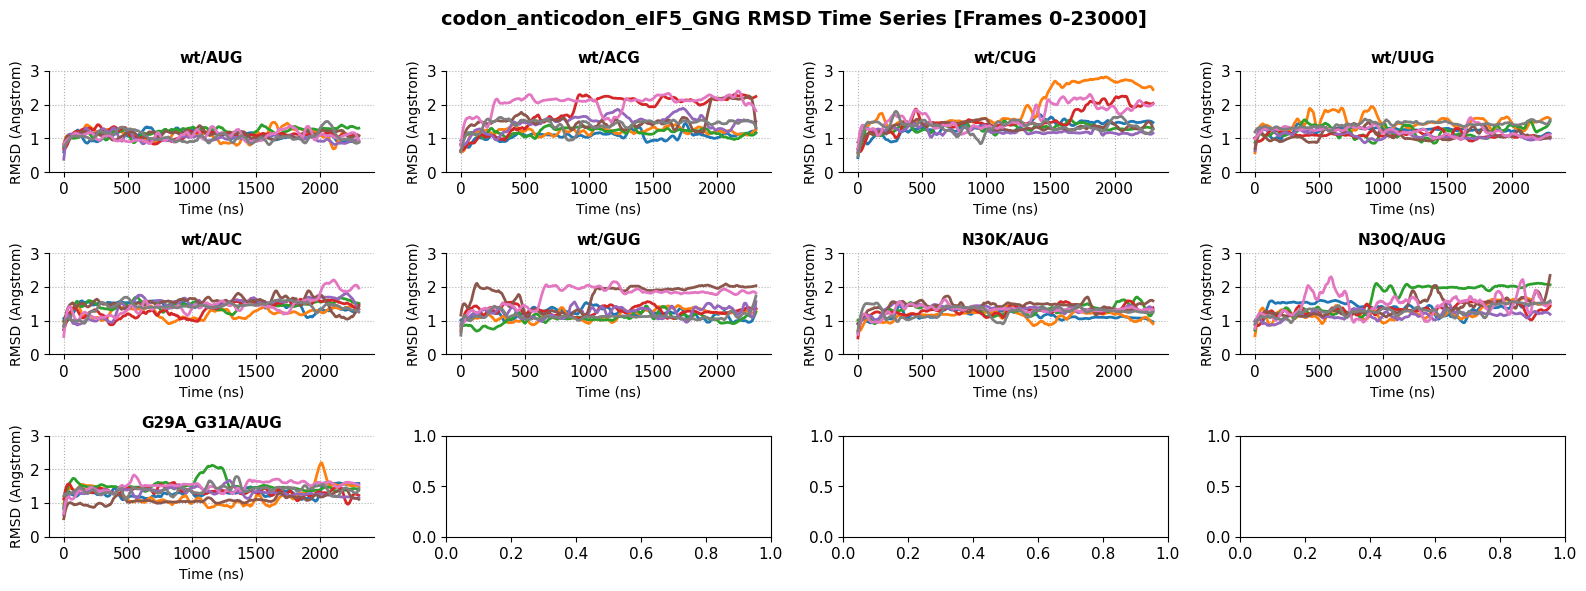

In [8]:
# Generate time series plots for each position
fig = plot_rmsd_timeseries(all_data, "codon_anticodon_eIF5_GNG")

plt.savefig("codon_anticodon_eIF5_GNG_timeseries.svg") 

## Bar Plots with Statistical Testing

Bar plots comparing mean RMSD across systems with:
- Mean values with SEM error bars
- Individual replicate values as jitter points
- One-way ANOVA for overall comparison
- Dunnett's test for pairwise comparisons to control

In [9]:
def calculate_replicate_means(
    all_data: Dict[str, Dict[str, Dict[str, np.ndarray]]],
    start_frame: int,
    end_frame: int
) -> pd.DataFrame:
    """
    Calculate mean RMSD for each replicate over specified frame range.
    
    Args:
        all_data: Complete RMSD dataset
        start_frame: First frame for averaging
        end_frame: Last frame for averaging
        
    Returns:
        DataFrame with System, Position, Clone, Mean_RMSD columns
    """
    results = []
    
    for system in SYSTEMS:
        if system not in all_data:
            continue
            
        for position in POSITIONS:
            if position not in all_data[system]:
                continue
                
            for clone_id, rmsd_values in all_data[system][position].items():
                mean_rmsd = np.mean(rmsd_values[start_frame:end_frame])
                
                results.append({
                    'System': system,
                    'Position': position,
                    'Clone': clone_id,
                    'Mean_RMSD': mean_rmsd
                })
    
    return pd.DataFrame(results)

In [10]:
# ============================================================
# ANALYSIS CONFIGURATION
# Set the frame range for bar plot analysis (after equilibration)
# ============================================================

ANALYSIS_START_FRAME = 13000   # Start frame (after equilibration)
ANALYSIS_END_FRAME = 23000    # End frame

print(f"Analysis Frame Range:")
print(f"  Start: {ANALYSIS_START_FRAME} ({ANALYSIS_START_FRAME * TIME_STEP:.0f} ns)")
print(f"  End:   {ANALYSIS_END_FRAME} ({ANALYSIS_END_FRAME * TIME_STEP:.0f} ns)")
print(f"  Duration: {(ANALYSIS_END_FRAME - ANALYSIS_START_FRAME) * TIME_STEP:.0f} ns")

Analysis Frame Range:
  Start: 13000 (1300 ns)
  End:   23000 (2300 ns)
  Duration: 1000 ns


In [11]:
# Calculate replicate means using the analysis frame range
mean_df = calculate_replicate_means(all_data, start_frame=ANALYSIS_START_FRAME, end_frame=ANALYSIS_END_FRAME)
print(f"Calculated means for {len(mean_df)} system-position-clone combinations")
print(f"Frame range: {ANALYSIS_START_FRAME} to {ANALYSIS_END_FRAME}\n")
display(mean_df.groupby(['System', 'Position'])['Mean_RMSD'].agg(['mean', 'sem', 'count']).round(4))

Calculated means for 576 system-position-clone combinations
Frame range: 13000 to 23000



mean     sem  count
System             Position                                       
eIF5_G29A_G31A_AUG anticodon_stem            0.8743  0.0344      8
                   anticodon_stem_heavy      1.1149  0.0666      8
                   codon_anticodon           0.5964  0.0276      8
                   codon_anticodon_eIF5_GNG  1.3521  0.0443      8
                   codon_anticodon_heavy     0.8249  0.0300      8
...                                             ...     ...    ...
eIF5wt_UUG         codon_anticodon_eIF5_GNG  1.2047  0.0571      8
                   codon_anticodon_heavy     0.9395  0.0222      8
                   codon_anticodon_pos1      0.9168  0.0189      8
                   codon_anticodon_pos2      0.5267  0.0254      8
                   codon_anticodon_pos3      0.6311  0.0632      8

[72 rows x 3 columns]

## Visualization

In [12]:

def plot_bar_with_statistics(
    mean_df: pd.DataFrame,
    selected_positions: List[str],
    selected_systems: List[str],
    control_system: str = CONTROL_SYSTEM,
    start_frame: int = None,
    end_frame: int = None,
    figsize: Tuple[float, float] = BAR_SUBPLOT_SIZE
) -> Tuple[plt.Figure, Dict]:
    """
    Create bar plots with statistical testing.
    
    Args:
        mean_df: DataFrame from calculate_replicate_means
        selected_positions: List of positions to plot
        selected_systems: List of systems to include
        control_system: Reference system for Dunnett's test
        start_frame: Start frame for title (optional)
        end_frame: End frame for title (optional)
        figsize: Figure size per subplot as (width, height)
        
    Returns:
        Tuple of (Figure, dict of statistical results per position)
    """
    n_positions = len(selected_positions)
    n_cols = min(n_positions, 3)
    n_rows = int(np.ceil(n_positions / n_cols))
    
    # Calculate total figure size based on subplot size
    total_width = figsize[0] * n_cols
    total_height = figsize[1] * n_rows
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(total_width, total_height), squeeze=False)
    axes = axes.flatten()
    
    # Use custom colors from SYSTEM_COLORS_MAP
    colors = [SYSTEM_COLORS_MAP.get(s, '#888888') for s in selected_systems]
    all_stats_results = {}
    
    for idx, position in enumerate(selected_positions):
        ax = axes[idx]
        
        pos_df = mean_df[(mean_df['Position'] == position) & 
                         (mean_df['System'].isin(selected_systems))].copy()
        
        # Calculate system means and SEMs
        system_stats = pos_df.groupby('System')['Mean_RMSD'].agg(['mean', 'sem'])
        system_stats = system_stats.reindex(selected_systems)
        
        x = np.arange(len(selected_systems))
        
        # Bar plot
        bars = ax.bar(x, system_stats['mean'],
                     color=colors,
                     edgecolor='black', linewidth=0.5, alpha=1.0, width = 0.5)
        
        # Error bars (SEM)
        ax.errorbar(x, system_stats['mean'],
                   yerr=system_stats['sem'],
                   fmt='none', color='black', capsize=3, capthick=1.5,
                   elinewidth=1.5, zorder=10)
        
        # Jitter points for individual replicates
        for i, system in enumerate(selected_systems):
            system_data = pos_df[pos_df['System'] == system]['Mean_RMSD'].values
            if len(system_data) > 0:
                np.random.seed(42)
                x_jitter = np.random.normal(i, 0.05, size=len(system_data))
                ax.scatter(x_jitter, system_data,
                          color='black', s=20, alpha=1.0, zorder=5,
                          edgecolors='white', linewidths=0.5)
        
        # Statistical testing
        all_groups = {s: pos_df[pos_df['System'] == s]['Mean_RMSD'].values 
                      for s in selected_systems}
        
        # One-way ANOVA
        f_stat, anova_p = stats.f_oneway(*[all_groups[s] for s in selected_systems 
                                           if len(all_groups[s]) > 0])
        
        # Dunnett's test vs control
        control_data = all_groups.get(control_system, np.array([]))
        treatment_systems = [s for s in selected_systems if s != control_system]
        treatment_data = [all_groups[s] for s in treatment_systems]
        
        pairwise_results = []
        significance_markers = [''] * len(selected_systems)
        
        if len(control_data) > 0 and len(treatment_data) > 0:
            dunnett_result = stats.dunnett(*treatment_data, control=control_data)
            
            for i, system in enumerate(treatment_systems):
                p_val = dunnett_result.pvalue[i]
                t_stat = dunnett_result.statistic[i]
                
                if p_val < 0.001:
                    sig = '***'
                elif p_val < 0.01:
                    sig = '**'
                elif p_val < 0.05:
                    sig = '*'
                else:
                    sig = 'ns'
                
                sys_idx = selected_systems.index(system)
                significance_markers[sys_idx] = sig
                
                pairwise_results.append({
                    'System': system,
                    't_stat': t_stat,
                    'p_value': p_val,
                    'significance': sig
                })
        
        # Add significance markers
        y_max = max(system_stats['mean'] + system_stats['sem'])
        y_offset = y_max * 0.05
        for i, marker in enumerate(significance_markers):
            if marker and marker != 'ns':
                ax.text(i, system_stats['mean'].iloc[i] + system_stats['sem'].iloc[i] + y_offset,
                       marker, ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        all_stats_results[position] = {
            'anova_f': f_stat,
            'anova_p': anova_p,
            'pairwise': pairwise_results
        }
        
        # Formatting
        x_labels = [SYSTEM_LABELS.get(s, s) for s in selected_systems]
        ax.set_xlabel('System', fontsize=11)
        ax.set_ylabel('Mean RMSD (Å)', fontsize=11)
        ax.set_title(POSITION_LABELS.get(position, position), fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Remove grid
        ax.grid(False)
        
        # Set tick parameters
        ax.tick_params(axis='both', which='major', direction='out', length=6, width=1, 
               color='black', labelcolor='black')
        ax.tick_params(axis='both', which='minor', direction='out', length=3, width=0.5, 
               color='black')
    
    # Hide unused subplots
    for idx in range(n_positions, len(axes)):
        axes[idx].set_visible(False)
    
    # Build title with frame range if provided
    if start_frame is not None and end_frame is not None:
        title = f'Mean RMSD Comparison (Frames {start_frame}-{end_frame})'
    else:
        title = 'Mean RMSD Comparison'
    #fig.suptitle(title, fontsize=14, fontweight='bold')
    #plt.tight_layout()
    
    return fig, all_stats_results


def print_statistics_summary(stats_results: Dict, control_system: str = CONTROL_SYSTEM) -> None:
    """
    Print formatted statistical summary.
    
    Args:
        stats_results: Dictionary from plot_bar_with_statistics
        control_system: Reference system name
    """
    print("\n" + "="*80)
    print("STATISTICAL ANALYSIS SUMMARY")
    print(f"Control group: {control_system}")
    print("Post-hoc test: Dunnett's test (comparisons to control)")
    print("Significance levels: * p<0.05, ** p<0.01, *** p<0.001")
    print("="*80)
    
    for position, results in stats_results.items():
        print(f"\n{POSITION_LABELS.get(position, position)}")
        print("-"*60)
        print(f"One-way ANOVA: F = {results['anova_f']:.4f}, p = {results['anova_p']:.4e}")
        print(f"\nDunnett's test vs {control_system}:")
        print(f"{'System':<25} {'t-stat':>10} {'p-value':>14} {'Sig':>6}")
        for r in results['pairwise']:
            print(f"{r['System']:<25} {r['t_stat']:>10.4f} {r['p_value']:>14.4e} {r['significance']:>6}")

## Codon+Anticodon+GNG


STATISTICAL ANALYSIS SUMMARY
Control group: eIF5wt_AUG
Post-hoc test: Dunnett's test (comparisons to control)
Significance levels: * p<0.05, ** p<0.01, *** p<0.001

codon_anticodon_eIF5_GNG
------------------------------------------------------------
One-way ANOVA: F = 3.9287, p = 5.1813e-03

Dunnett's test vs eIF5wt_AUG:
System                        t-stat        p-value    Sig
eIF5wt_CUG                    3.5736     4.0379e-03     **
eIF5wt_GUG                    2.0084     1.8260e-01     ns
eIF5wt_UUG                    0.7703     9.0265e-01     ns
eIF5wt_ACG                    3.1579     1.2785e-02      *
eIF5wt_AUC                    2.7074     4.0032e-02      *


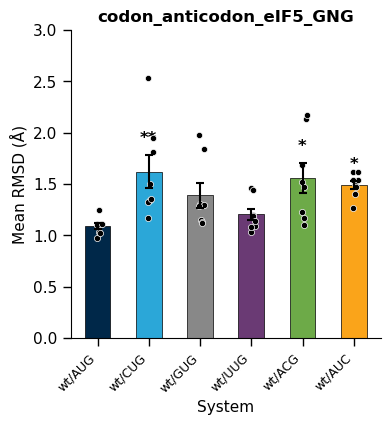

In [13]:
# ============================================================
# USER SELECTION: Modify these lists to change the comparison
# ============================================================

# Select positions to plot (can be 1-3)
SELECTED_POSITIONS = ['codon_anticodon_eIF5_GNG']

# Select systems to compare
SELECTED_SYSTEMS = ['eIF5wt_AUG', 'eIF5wt_CUG', 'eIF5wt_GUG', 'eIF5wt_UUG', 'eIF5wt_ACG', 'eIF5wt_AUC']

# Control system for statistical testing
CONTROL_SYSTEM = 'eIF5wt_AUG'

# ============================================================

# Generate plots and statistics
fig, stats_results = plot_bar_with_statistics(
    mean_df, 
    SELECTED_POSITIONS, 
    SELECTED_SYSTEMS,
    CONTROL_SYSTEM,
    start_frame=ANALYSIS_START_FRAME,
    end_frame=ANALYSIS_END_FRAME,
    figsize = (4,4)
)

plt.ylim([0,3])
plt.yticks(np.arange(0,3.5,0.5))
plt.tick_params(axis='both', which='major', direction='out', length=6, width=1, 
               color='black', labelcolor='black')
plt.tick_params(axis='both', which='minor', direction='out', length=3, width=0.5, 
               color='black')

plt.savefig("rmsd_codon_anticodon_GNG_startsites.svg", transparent=True)

# Print statistical summary
print_statistics_summary(stats_results, CONTROL_SYSTEM)


STATISTICAL ANALYSIS SUMMARY
Control group: eIF5wt_AUG
Post-hoc test: Dunnett's test (comparisons to control)
Significance levels: * p<0.05, ** p<0.01, *** p<0.001

codon_anticodon_eIF5_GNG
------------------------------------------------------------
One-way ANOVA: F = 8.7343, p = 3.0039e-04

Dunnett's test vs eIF5wt_AUG:
System                        t-stat        p-value    Sig
eIF5_N30Q_AUG                 5.0154     7.2070e-05    ***
eIF5_N30K_AUG                 2.6041     3.8252e-02      *
eIF5_G29A_G31A_AUG            3.3711     6.1085e-03     **


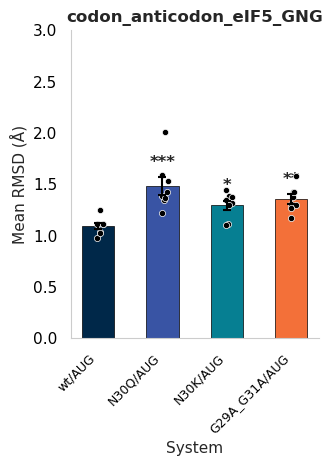

In [239]:
# ============================================================
# USER SELECTION: Modify these lists to change the comparison
# ============================================================

# Select positions to plot (can be 1-3)
SELECTED_POSITIONS = ['codon_anticodon_eIF5_GNG']

# Select systems to compare
MUTANT_COMPARISON_SYSTEMS = [
    'eIF5wt_AUG', 
    'eIF5_N30Q_AUG',
    'eIF5_N30K_AUG',  
    'eIF5_G29A_G31A_AUG'
]
# Control system for statistical testing
CONTROL_SYSTEM = 'eIF5wt_AUG'

# ============================================================

# Generate plots and statistics
fig, stats_results = plot_bar_with_statistics(
    mean_df, 
    SELECTED_POSITIONS, 
    MUTANT_COMPARISON_SYSTEMS,
    CONTROL_SYSTEM,
    start_frame=ANALYSIS_START_FRAME,
    end_frame=ANALYSIS_END_FRAME,
    figsize = (4/5*4,4)
)

plt.ylim([0,3])
plt.yticks(np.arange(0,3.5,0.5))
plt.tick_params(axis='both', which='major', direction='out', length=6, width=1, 
               color='black', labelcolor='black')
plt.tick_params(axis='both', which='minor', direction='out', length=3, width=0.5, 
               color='black')

plt.savefig("rmsd_codon_anticodon_GNG_eif5mutants.svg", transparent=True)



# Print statistical summary
print_statistics_summary(stats_results, CONTROL_SYSTEM)

#### Compare start sites

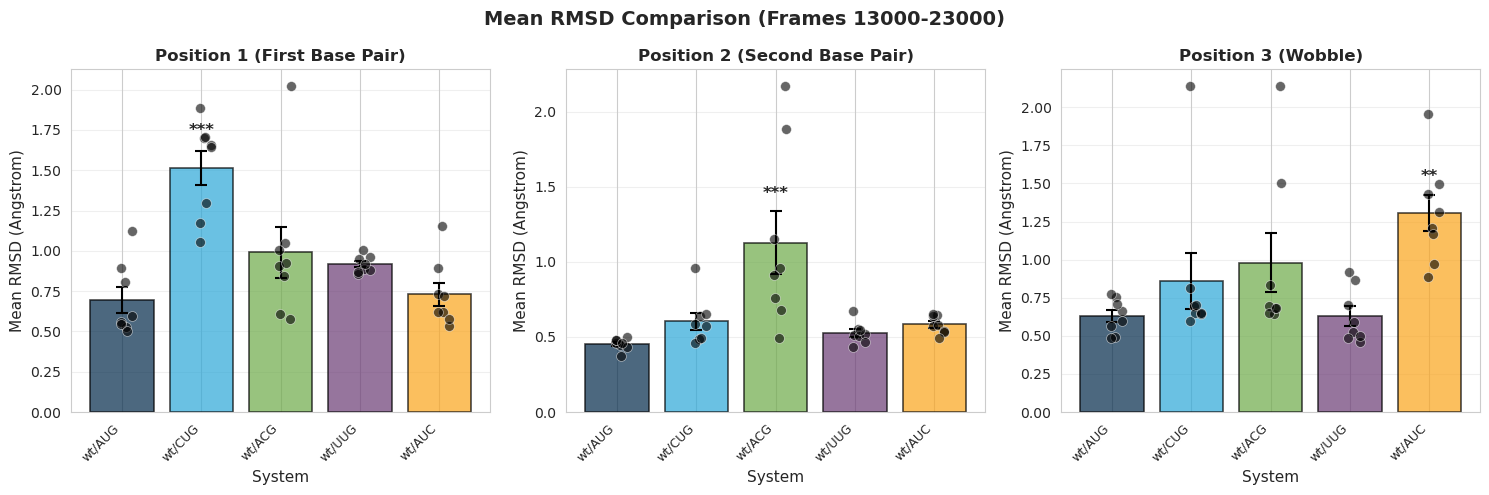


STATISTICAL ANALYSIS SUMMARY
Control group: eIF5wt_AUG
Post-hoc test: Dunnett's test (comparisons to control)
Significance levels: * p<0.05, ** p<0.01, *** p<0.001

Position 1 (First Base Pair)
------------------------------------------------------------
One-way ANOVA: F = 11.2132, p = 5.8310e-06

Dunnett's test vs eIF5wt_AUG:
System                        t-stat        p-value    Sig
eIF5wt_CUG                    5.9003     3.1341e-06    ***
eIF5wt_ACG                    2.1330     1.2453e-01     ns
eIF5wt_UUG                    1.5938     3.3069e-01     ns
eIF5wt_AUC                    0.2582     9.9685e-01     ns

Position 2 (Second Base Pair)
------------------------------------------------------------
One-way ANOVA: F = 7.3997, p = 1.9834e-04

Dunnett's test vs eIF5wt_AUG:
System                        t-stat        p-value    Sig
eIF5wt_CUG                    1.0979     6.4576e-01     ns
eIF5wt_ACG                    4.8361     1.0239e-04    ***
eIF5wt_UUG                    0.5

In [145]:
# ============================================================
# USER SELECTION: Modify these lists to change the comparison
# ============================================================

# Select positions to plot (can be 1-3)
SELECTED_POSITIONS = ['codon_anticodon_pos1', 'codon_anticodon_pos2', 'codon_anticodon_pos3']

# Select systems to compare
SELECTED_SYSTEMS = ['eIF5wt_AUG', 'eIF5wt_CUG', 'eIF5wt_ACG', 'eIF5wt_UUG', 'eIF5wt_AUC']

# Control system for statistical testing
CONTROL_SYSTEM = 'eIF5wt_AUG'

# ============================================================

# Generate plots and statistics
fig, stats_results = plot_bar_with_statistics(
    mean_df, 
    SELECTED_POSITIONS, 
    SELECTED_SYSTEMS,
    CONTROL_SYSTEM,
    start_frame=ANALYSIS_START_FRAME,
    end_frame=ANALYSIS_END_FRAME
)
plt.show()

# Print statistical summary
print_statistics_summary(stats_results, CONTROL_SYSTEM)

#### Compare Mutants vs Wild-Type (AUG only)

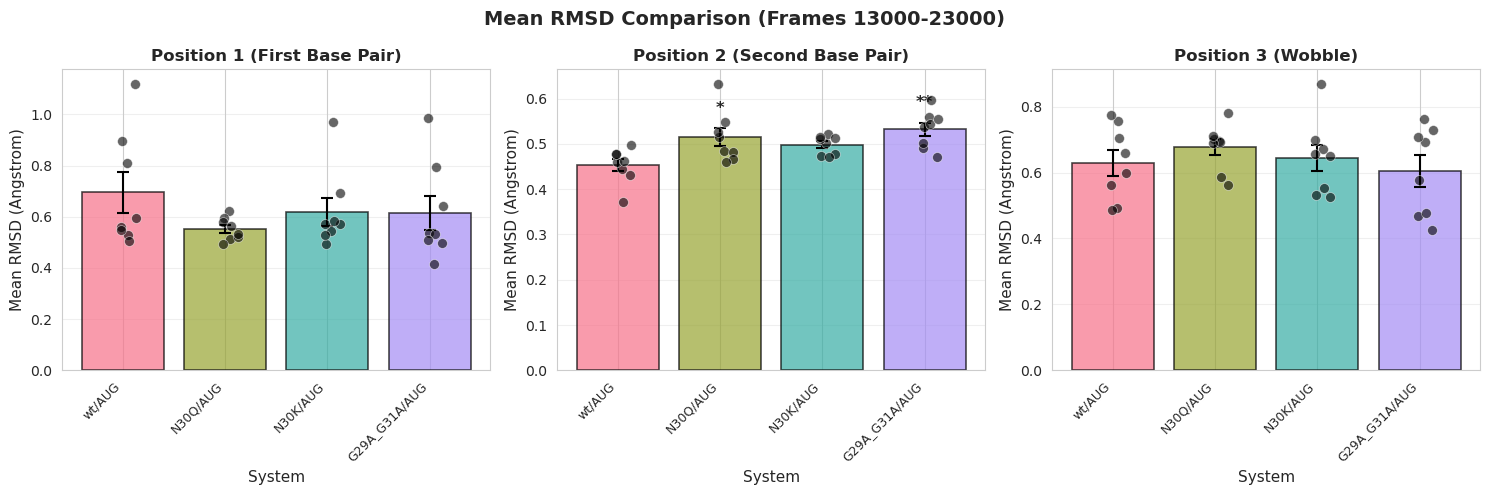


STATISTICAL ANALYSIS SUMMARY
Control group: eIF5wt_AUG
Post-hoc test: Dunnett's test (comparisons to control)
Significance levels: * p<0.05, ** p<0.01, *** p<0.001

Position 1 (First Base Pair)
------------------------------------------------------------
One-way ANOVA: F = 0.9861, p = 4.1351e-01

Dunnett's test vs eIF5wt_AUG:
System                        t-stat        p-value    Sig
eIF5_N30Q_AUG                -1.7151     2.2723e-01     ns
eIF5_N30K_AUG                -0.9086     6.9242e-01     ns
eIF5_G29A_G31A_AUG           -0.9686     6.5174e-01     ns

Position 2 (Second Base Pair)
------------------------------------------------------------
One-way ANOVA: F = 5.3876, p = 4.6914e-03

Dunnett's test vs eIF5wt_AUG:
System                        t-stat        p-value    Sig
eIF5_N30Q_AUG                 2.9808     1.5944e-02      *
eIF5_N30K_AUG                 2.2002     9.0992e-02     ns
eIF5_G29A_G31A_AUG            3.8255     1.8800e-03     **

Position 3 (Wobble)
-------------

In [136]:
# Compare eIF5 mutants with AUG codon
MUTANT_COMPARISON_SYSTEMS = [
    'eIF5wt_AUG', 
    'eIF5_N30Q_AUG',
    'eIF5_N30K_AUG',  
    'eIF5_G29A_G31A_AUG'
]

fig, stats_results = plot_bar_with_statistics(
    mean_df, 
    SELECTED_POSITIONS, 
    MUTANT_COMPARISON_SYSTEMS,
    'eIF5wt_AUG',
    start_frame=ANALYSIS_START_FRAME,
    end_frame=ANALYSIS_END_FRAME
)
plt.show()

print_statistics_summary(stats_results, 'eIF5wt_AUG')

### Anticodon stem of tRNA

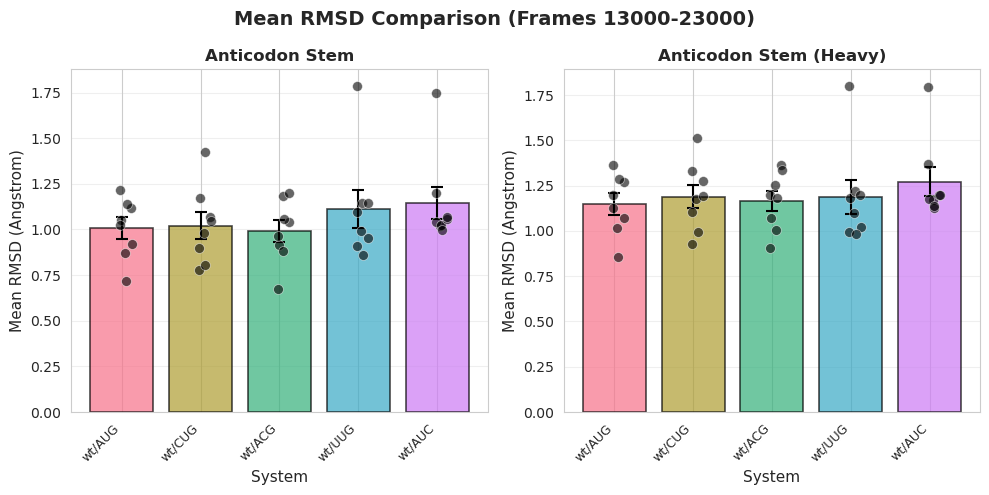


STATISTICAL ANALYSIS SUMMARY
Control group: eIF5wt_AUG
Post-hoc test: Dunnett's test (comparisons to control)
Significance levels: * p<0.05, ** p<0.01, *** p<0.001

Anticodon Stem
------------------------------------------------------------
One-way ANOVA: F = 0.7440, p = 5.6859e-01

Dunnett's test vs eIF5wt_AUG:
System                        t-stat        p-value    Sig
eIF5wt_CUG                    0.1215     9.9984e-01     ns
eIF5wt_ACG                   -0.1591     9.9952e-01     ns
eIF5wt_UUG                    0.9224     7.6479e-01     ns
eIF5wt_AUC                    1.2167     5.6340e-01     ns

Anticodon Stem (Heavy)
------------------------------------------------------------
One-way ANOVA: F = 0.4309, p = 7.8529e-01

Dunnett's test vs eIF5wt_AUG:
System                        t-stat        p-value    Sig
eIF5wt_CUG                    0.3999     9.8369e-01     ns
eIF5wt_ACG                    0.1547     9.9957e-01     ns
eIF5wt_UUG                    0.3807     9.8637e-01    

In [137]:
# ============================================================
# USER SELECTION: Modify these lists to change the comparison
# ============================================================

# Select positions to plot (can be 1-3)
SELECTED_POSITIONS = ['anticodon_stem','anticodon_stem_heavy']

# Select systems to compare
SELECTED_SYSTEMS = ['eIF5wt_AUG', 'eIF5wt_CUG', 'eIF5wt_ACG', 'eIF5wt_UUG', 'eIF5wt_AUC']

# Control system for statistical testing
CONTROL_SYSTEM = 'eIF5wt_AUG'

# ============================================================

# Generate plots and statistics
fig, stats_results = plot_bar_with_statistics(
    mean_df, 
    SELECTED_POSITIONS, 
    SELECTED_SYSTEMS,
    CONTROL_SYSTEM,
    start_frame=ANALYSIS_START_FRAME,
    end_frame=ANALYSIS_END_FRAME
)
plt.show()

# Print statistical summary
print_statistics_summary(stats_results, CONTROL_SYSTEM)

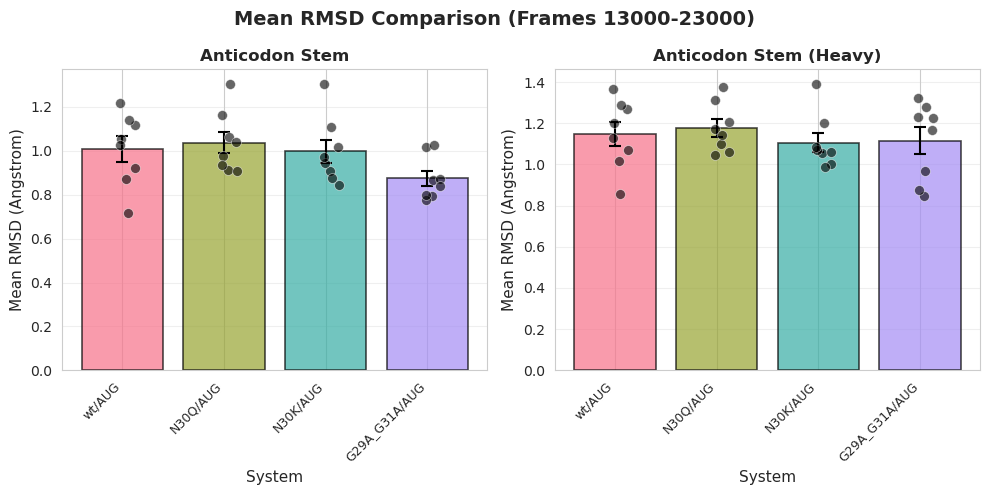


STATISTICAL ANALYSIS SUMMARY
Control group: eIF5wt_AUG
Post-hoc test: Dunnett's test (comparisons to control)
Significance levels: * p<0.05, ** p<0.01, *** p<0.001

Anticodon Stem
------------------------------------------------------------
One-way ANOVA: F = 2.1342, p = 1.1834e-01

Dunnett's test vs eIF5wt_AUG:
System                        t-stat        p-value    Sig
eIF5_N30Q_AUG                 0.4216     9.5208e-01     ns
eIF5_N30K_AUG                -0.1460     9.9774e-01     ns
eIF5_G29A_G31A_AUG           -1.9173     1.5804e-01     ns

Anticodon Stem (Heavy)
------------------------------------------------------------
One-way ANOVA: F = 0.3578, p = 7.8387e-01

Dunnett's test vs eIF5wt_AUG:
System                        t-stat        p-value    Sig
eIF5_N30Q_AUG                 0.3641     9.6801e-01     ns
eIF5_N30K_AUG                -0.5556     9.0058e-01     ns
eIF5_G29A_G31A_AUG           -0.4428     9.4525e-01     ns


In [138]:
# Compare eIF5 mutants with AUG codon
MUTANT_COMPARISON_SYSTEMS = [
    'eIF5wt_AUG', 
    'eIF5_N30Q_AUG',
    'eIF5_N30K_AUG',  
    'eIF5_G29A_G31A_AUG'
]

fig, stats_results = plot_bar_with_statistics(
    mean_df, 
    SELECTED_POSITIONS, 
    MUTANT_COMPARISON_SYSTEMS,
    'eIF5wt_AUG',
    start_frame=ANALYSIS_START_FRAME,
    end_frame=ANALYSIS_END_FRAME
)
plt.show()

print_statistics_summary(stats_results, 'eIF5wt_AUG')

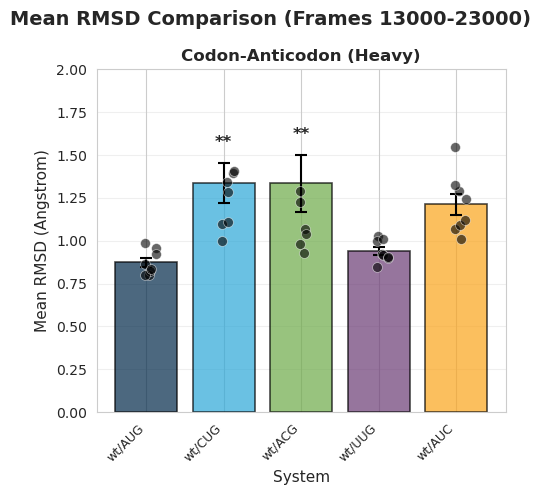


STATISTICAL ANALYSIS SUMMARY
Control group: eIF5wt_AUG
Post-hoc test: Dunnett's test (comparisons to control)
Significance levels: * p<0.05, ** p<0.01, *** p<0.001

Codon-Anticodon (Heavy)
------------------------------------------------------------
One-way ANOVA: F = 5.1750, p = 2.2079e-03

Dunnett's test vs eIF5wt_AUG:
System                        t-stat        p-value    Sig
eIF5wt_CUG                    3.3952     6.2406e-03     **
eIF5wt_ACG                    3.3794     6.5221e-03     **
eIF5wt_UUG                    0.4862     9.6722e-01     ns
eIF5wt_AUC                    2.4726     6.0597e-02     ns


In [146]:
# ============================================================
# USER SELECTION: Modify these lists to change the comparison
# ============================================================

# Select positions to plot (can be 1-3)
SELECTED_POSITIONS = ['codon_anticodon_heavy']

# Select systems to compare
SELECTED_SYSTEMS = ['eIF5wt_AUG', 'eIF5wt_CUG', 'eIF5wt_ACG', 'eIF5wt_UUG', 'eIF5wt_AUC']

# Control system for statistical testing
CONTROL_SYSTEM = 'eIF5wt_AUG'

# ============================================================

# Generate plots and statistics
fig, stats_results = plot_bar_with_statistics(
    mean_df, 
    SELECTED_POSITIONS, 
    SELECTED_SYSTEMS,
    CONTROL_SYSTEM,
    start_frame=ANALYSIS_START_FRAME,
    end_frame=ANALYSIS_END_FRAME
)

plt.ylim([0,2])
plt.show()

# Print statistical summary
print_statistics_summary(stats_results, CONTROL_SYSTEM)

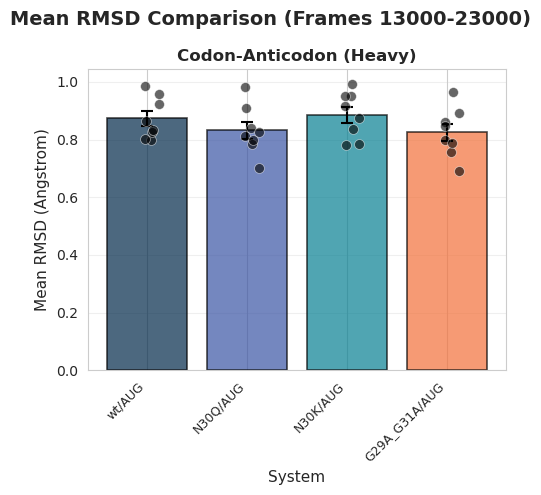


STATISTICAL ANALYSIS SUMMARY
Control group: eIF5wt_AUG
Post-hoc test: Dunnett's test (comparisons to control)
Significance levels: * p<0.05, ** p<0.01, *** p<0.001

Codon-Anticodon (Heavy)
------------------------------------------------------------
One-way ANOVA: F = 1.1223, p = 3.5681e-01

Dunnett's test vs eIF5wt_AUG:
System                        t-stat        p-value    Sig
eIF5_N30Q_AUG                -1.0263     6.1246e-01     ns
eIF5_N30K_AUG                 0.3210     9.7755e-01     ns
eIF5_G29A_G31A_AUG           -1.1963     4.9938e-01     ns


In [147]:
# Compare eIF5 mutants with AUG codon
MUTANT_COMPARISON_SYSTEMS = [
    'eIF5wt_AUG', 
    'eIF5_N30Q_AUG',
    'eIF5_N30K_AUG',  
    'eIF5_G29A_G31A_AUG'
]

fig, stats_results = plot_bar_with_statistics(
    mean_df, 
    SELECTED_POSITIONS, 
    MUTANT_COMPARISON_SYSTEMS,
    'eIF5wt_AUG',
    start_frame=ANALYSIS_START_FRAME,
    end_frame=ANALYSIS_END_FRAME
)
plt.show()

print_statistics_summary(stats_results, 'eIF5wt_AUG')